In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


tips = sns.load_dataset('tips')

# Themeing

* `set_theme`

> Set aspects of the visual theme for all matplotlib and seaborn plots.

* `axes_style`

> Get the parameters that control the general style of the plots.

* `set_style`

> Set the parameters that control the general style of the plots.

* `plotting_context`

> Get the parameters that control the scaling of plot elements.

* `set_context`

> Set the parameters that control the scaling of plot elements.

* `set_color_codes`

> Change how matplotlib color shorthands are interpreted.

* `reset_defaults`

> Restore all RC params to default settings.

* `reset_orig`

> Restore all RC params to original settings (respects custom rc).


## `set_theme` function : 
> This function is used to set the theme of your plots, it can take a variety of inputs such as 'darkgrid', 'whitegrid', 'dark', 'white' or 'ticks'.

Example: 

In [ ]:
tips.head()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

In [ ]:
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

<Figure size 640x480 with 1 Axes>

## 🔬 Deep Dive : set_theme — global plot style

```python
sns.set_theme(style='whitegrid')      # high-level all-in-one theming
```

- set_theme — global defaults: style + palette + context + font
- style values: 'white', 'dark', 'whitegrid', 'darkgrid', 'ticks'
- grid → readability; white ⇒ clean print
- Applies to all subsequent seaborn/matplotlib plots
- Runs once at notebook start for consistency
- `.set()` — persistent | axes_style(context manager) — temporary
- Example bars show instantly visual difference
- matplotlib affects too; default keys in seaborn style dict
- choose aesthetic — background choice determines tint
- call early — later plots consistent

In [ ]:
# Using whitegrid
sns.set_theme(style='whitegrid')
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

<Figure size 640x480 with 1 Axes>

In [ ]:
# Using dark background 
sns.set_theme(style='dark')
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

<Figure size 640x480 with 1 Axes>

## `axes_style` function :

This function is used to set the style of the axes of your plots. It can take a variety of inputs such as 'white', 'dark', 'ticks' or a dictionary with key-value pairs of valid style options.


In [ ]:
# Example: 
sns.axes_style(style = 'white')
sns.barplot(x=["A", "B", "C"], y=[1, 3, 2])

<Figure size 640x480 with 1 Axes>

## 🔬 Deep Dive : axes_style & set_context

```python
sns.axes_style('white')               # inspect/set axes style
with sns.axes_style('whitegrid'):
    sns.scatterplot(...)              # temporary style block only

sns.set_context('poster')             # scale everything larger
sns.set_context('paper', font_scale=1.5)   # custom sized
```

- axes_style — coordinated axes look (grid, ticks, spines)
- context manager — style applies INSIDE `with` block only → scoped
- set_context: 'paper','notebook','talk','poster' — scale text/lines
- rcParams interplay: fonts, gridsize, tick sizes
- palette/font scale passing
- per-block style uniqueness — presentation vs notebook
- visual size ladder small→huge output
- Multiple axes_style: dict override
- Readable slide figures → context 'talk'/'poster'
- grid width/font relation matches labelling

In [ ]:
# Use the function as a context manager to temporarily change the style of your plots:

with sns.axes_style("white"):
    sns.barplot(x=[1, 2, 3], y=[2, 5, 3])

<Figure size 640x480 with 1 Axes>

In [ ]:
# Load the iris data
iris = sns.load_dataset("iris")

# Set the style of the axes to "darkgrid"
sns.set_style("whitegrid")

# Create a scatter plot of sepal length vs sepal width
sns.scatterplot(x="sepal_length", y="sepal_width", data=iris)

# Show the plot
plt.show()


<Figure size 640x480 with 1 Axes>

## Scaling Figure Styles - `sns.set_context()`

Matplotlib allows you to generate powerful plots, but styling those plots for different presentation purposes is difficult. Seaborn makes it easy to produce the same plots in a variety of different visual formats so you can customize the presentation of your data for the appropriate context, whether it be a research paper or a conference poster.

You can set the visual format, or context, using `sns.set_context()`

Within the usage of `sns.set_context()`, there are three levels of complexity:

* Pass in one parameter that adjusts the scale of the plot
* Pass in two parameters - one for the scale and the other for the font size
* Pass in three parameters - including the previous two, as well as the rc with the style parameter that you want to override

### Scaling Plots
Seaborn has four presets which set the size of the plot and allow you to customize your figure depending on how it will be presented.

In order of relative size they are: `paper`, `notebook`, `talk`, and `poster`. The notebook style is the default.

In [ ]:
sns.set_style("ticks")

# Smallest context: paper
sns.set_context("paper")
sns.stripplot(x="day", y="total_bill", data=tips)

<Figure size 640x480 with 1 Axes>

In [ ]:
sns.set_style("ticks")

# Largest Context: poster
sns.set_context("poster")
sns.stripplot(x="day", y="total_bill", data=tips)

<Figure size 640x480 with 1 Axes>

### Scaling Fonts and Line Widths

You are also able to change the size of the text using the font_scale parameter for `sns.set_context()`

You may want to also change the line width so it matches. We do this with the rc parameter, which we’ll explain in detail below.



In [ ]:
# Set font scale and reduce grid line width to match
sns.set_style("darkgrid")

sns.set_context("poster", font_scale = .5, rc={"grid.linewidth": 1.5})
sns.stripplot(x="day", y="total_bill", data=tips)

<Figure size 640x480 with 1 Axes>

> While you’re able to change these parameters, you should keep in mind that it’s not always useful to make certain changes. Notice in this example that we’ve changed the line width, but because of it’s relative size to the plot, it distracts from the actual plotted data.



In [ ]:
# Set font scale and increase grid line width to match
sns.set_context("poster", font_scale = .8, rc={"grid.linewidth": 5})
sns.stripplot(x="day", y="total_bill", data=tips)

<Figure size 640x480 with 1 Axes>

### The RC Parameter

As we mentioned above, if you want to override any of these standards, you can use `sns.set_context` and pass in the parameter rc to target and reset the value of an individual parameter in a dictionary. `rc` stands for the phrase ‘run command’ - essentially, configurations which will execute when you run your code.

In [ ]:
# Plotting context function

sns.plotting_context() 
# These are the property you can tweak in rc parameter

{'font.size': 19.200000000000003,
 'axes.labelsize': 19.200000000000003,
 'axes.titlesize': 19.200000000000003,
 'xtick.labelsize': 17.6,
 'ytick.labelsize': 17.6,
 'legend.fontsize': 17.6,
 'axes.linewidth': 2.5,
 'grid.linewidth': 5.0,
 'lines.linewidth': 3.0,
 'lines.markersize': 12.0,
 'patch.linewidth': 2.0,
 'xtick.major.width': 2.5,
 'ytick.major.width': 2.5,
 'xtick.minor.width': 2.0,
 'ytick.minor.width': 2.0,
 'xtick.major.size': 12.0,
 'ytick.major.size': 12.0,
 'xtick.minor.size': 8.0,
 'ytick.minor.size': 8.0,
 'legend.title_fontsize': 19.200000000000003}

## `seaborn.set_color_codes(palette=’deep’)`

Change how matplotlib color shorthands are interpreted.

Calling this will change how shorthand codes like “b” or “g” are interpreted by matplotlib in subsequent plots.

Parameters:	
> `palette` : `{deep, muted, pastel, dark, bright, colorblind}`
Named seaborn palette to use as the source of colors.

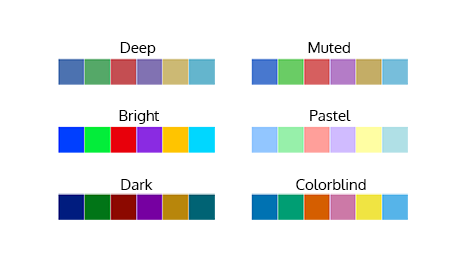


## 🔬 Deep Dive : set_color_codes & palettes

```python
sns.set_color_codes(palette='deep')    # 'b' → deep blue, 'g' → deep green
sns.set_color_codes(palette='pastel')  # same codes different palette
```

- color_codes: matplotlib letter shortcuts ('b','g','r','c','m','y','k')
- palette swap — RIDE letter → different shade
- deep/pastel — distinct family volumes
- convenient for existing matplotlib-style code
- set_palette — global color cycle for seaborn plots
- color_palette('deep', n) — generate n colors
- custom palette: hex list → color_palette([...])
- as_cmap=True — palette→heatmap colormap
- palettes: qualitative (deep/pastel/husl), sequential (viridis/magma), diverging
- ColorBrand coherent visuals

In [ ]:
# 'b' color code with deep palette 
sns.set_color_codes(palette='deep')
sns.relplot(data=tips, x='total_bill', y='tip', color='b')

<Figure size 500x500 with 1 Axes>

In [ ]:
# 'b' color code with pastel palette 
sns.set_color_codes(palette='pastel')
sns.relplot(data=tips, x='total_bill', y='tip', color='b')

<Figure size 500x500 with 1 Axes>

# Color palettes

* set_palette

> Set the matplotlib color cycle using a seaborn palette.

* color_palette

> Return a list of colors or continuous colormap defining a palette.

* husl_palette

> Return hues with constant lightness and saturation in the HUSL system.

* hls_palette

> Return hues with constant lightness and saturation in the HLS system.

* cubehelix_palette

> Make a sequential palette from the cubehelix system.

* dark_palette

> Make a sequential palette that blends from dark to color.

* light_palette

> Make a sequential palette that blends from light to color.

* diverging_palette

> Make a diverging palette between two HUSL colors.

* blend_palette

> Make a palette that blends between a list of colors.

* xkcd_palette

> Make a palette with color names from the xkcd color survey.

* crayon_palette

> Make a palette with color names from Crayola crayons.

* mpl_palette

> Return a palette or colormap from the matplotlib registry.

### `color_palette`

https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette

In Seaborn, the `color_palette()` function allows you to easily specify the colors for your plots. You can use pre-defined palettes, such as "deep", "muted", "pastel", "bright", "dark", and "colorblind", or you can create your own custom palette.

When using a pre-defined palette, you can specify the number of colors you want to use by passing in the desired number as the argument. 

For example, using the "deep" palette and specifying 6 colors will return an array of 6 RGB color codes that can be used in your plot.

## 🔬 Deep Dive : color_palette & cubehelix

```python
deep_colors = sns.color_palette("deep", 6)         # top 6 colors deep
colors = sns.color_palette(["#00CD00", "#00FFAA", "#FCCC00", "#FF0000"])
sns.color_palette("husl", 8, .7)                    # hue-const lightness
sns.cubehelix_palette(8, start=.5, rot=-.75, gamma=.3, light=.9, dark=.1, reverse=True)
sns.set_palette("husl", n_colors=8)                 # global color cycle
```

- color_palette(name, n) — return list of n RGB tuples
- named: deep/muted/bright/pastel/dark, hls/husl, Sequential, diverging
- custom list of hex → explicit color wants
- set_palette — global default color for future plots (pythonic)
- cubehelix: perceptually uniform rainbow sequence — great heatmaps
- start/rot/gamma control shift; light/dark bounds; reverse flip
- barplot palette= same list reuse
- color choice affects categorical distinction
- sequential for ordered data value; qualitative for labels
- nice formatting: sns.color_palette("Paired") — paired groups

In [ ]:
deep_colors = sns.color_palette("deep", 6)

# Just to show the color palette using palplot
sns.palplot(deep_colors)
plt.show()

<Figure size 600x100 with 1 Axes>

You can also create your own custom color palette by passing in a list of RGB color codes.

In [ ]:
colors = ["#00CD00", "#00FFAA", "#FCCC00", "#FF0000"]
colors = sns.color_palette(colors)
sns.palplot(colors)
plt.show()

<Figure size 400x100 with 1 Axes>

The `as_cmap` parameter in seaborn's `color_palette` function is a boolean flag that, when set to True, returns a colormap object instead of a list of RGB values. This can be useful when plotting data that needs to be colored based on a continuous variable, such as a heatmap or a 2D histogram. The colormap can then be passed to other plotting functions, such as heatmap or imshow, to color the plotted data. An example of using color_palette with as_cmap is:


## 🔬 Deep Dive : Color to colormap (cmap)

```python
cmap = sns.color_palette('Blues', as_cmap=True)   # palette → colormap
sns.heatmap(data, cmap=cmap)                      # use on continuous data
cmap = sns.color_palette(["#00CD00","#FF0000"], as_cmap=True)   # custom 2-color
```

- color_palette(...).as_cmap — palette of discrete colors → continuous colormap
- sequential palettes ('Blues','Greens','Reds','viridis','rocket') → heatmaps
- custom hex list → 2/3-stop colormap
- corr() → correlation matrix cell colors
- readability: choose sequential for magnitude; diverging for +/- signed
- palette param passed to plotting (heatmap cmap= overrides)
- hex_colors = sns.color_palette("husl", 8, 0.7).as_hex()
- consistent color language across graphs
- matrix heatmaps practitioners always use cmap
- as_cmap comes into play with sns heatmap directly

In [ ]:
data = tips.corr()

# Create a colormap from a seaborn color palette
cmap = sns.color_palette("Blues", as_cmap=True)

# Create a heatmap using the colormap
sns.heatmap(data, cmap=cmap)
plt.show()

<Figure size 640x480 with 2 Axes>

In [ ]:
data = tips.corr()

# Create a colormap using your own custom color code
colors = ["#FFFF00", "#00FFAA", "#FCCCDD", "#FCCC00"]
cmap = sns.color_palette(colors, as_cmap=True)

# Create a heatmap using the colormap
sns.heatmap(data, cmap=cmap)
plt.show()

<Figure size 640x480 with 2 Axes>

## `set_palette`
The `set_palette()` function in seaborn allows you to specify a color palette for your plots. This can be done by passing in one of the pre-defined seaborn palettes (such as "deep", "muted", "bright", etc.) or by passing in your own custom list of colors or color_palette.

Here is an example of using set_palette() to specify the "deep" palette:

In [ ]:
# This will set palette as deep
sns.set_palette('deep')
sns.lineplot(data=tips, x='tip', y='total_bill')
plt.show()

<Figure size 640x480 with 1 Axes>

In [ ]:
# Loading different data
import plotly.express as px

gap = px.data.gapminder()
gap.head()

       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  

You can also pass in a custom list of colors. For example, the following code would set the palette to the colors red, blue, and green:



In [ ]:
temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]

# Seting palette to three colors
sns.set_palette(["red", "blue", "green"])
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')



<Figure size 700.5x500 with 1 Axes>

You can also pass in a number of different arguments to set_palette. For example, the following code sets the color palette to a specific hue, with 8 colors, and a desaturated lightness:




In [ ]:
sns.set_palette("husl", 8, .7)
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')

<Figure size 700.5x500 with 1 Axes>

Now say we have set pallete colors and passed three colors, like we did above and want to plot of 4 or more country line plots? 

What color will be assinged to 4th country? Let's see

In [ ]:
temp_df = gap[gap['country'].isin(['India','Brazil','Germany','Afghanistan'])]

# Seting palette to three colors
sns.set_palette(["red", "blue", "green"])
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')



<Figure size 734x500 with 1 Axes>

See it took, color palette we set as - sns.set_palette("husl",8, .7), with eight colors. Even if we are specifying set palette as `['red', 'blue', 'green']`


In [ ]:
temp_df = gap[gap['country'].isin(['India','Brazil','Germany','Afghanistan'])]

# Seting palette to four colors 
sns.set_palette(["red", "blue", "green", 'yellow'])
sns.relplot(data=temp_df, kind='scatter', x='year', y='lifeExp', hue='country')

# This will give right expected result as it has enough colors in the palette to show.

<Figure size 734x500 with 1 Axes>

## seaborn.husl_palette

`seaborn.husl_palette(n_colors=6, h=0.01, s=0.9, l=0.65, as_cmap=False)`
> Return hues with constant lightness and saturation in the HUSL system.

> The hues are evenly sampled along a circular path. The resulting palette will be appropriate for categorical or cyclical data.

> The `h`, `l`, and `s` values should be between 0 and 1.


Parameters:
> `n_colors` : `int` Number of colors in the palette.

> `h` : `float` (0-1) The value of the first hue.

> `l` : `float` (0-1)  The lightness value.

> `s`: `float` (0-1) The saturation intensity.

> `as_cmap` : `bool` If True, return a matplotlib colormap object.


`sns.hls_palette()` > This function is similar to husl_palette(), but it uses a nonlinear color space that is more perceptually uniform, and saturation in the HLS system.

We can also use 'husl' or 'hsl' parameter in set_palette function for the same. Like we did in above example.

In [ ]:
# Iris data loading
iris = sns.load_dataset('iris')

## cubehelix_palette

The seaborn.cubehelix_palette function is used to generate a colormap based on the cubehelix color scheme, which is a sequential color map with a linear increase in brightness and a smooth progression through the hues of the spectrum. 
This function takes several optional parameters such as `start`, `rot`, `gamma`, `light`, `dark`, `reverse` and `as_cmap` to control the properties of the color palette.

For example, the following code generates a cubehelix color palette with 8 colors, starting from a blue hue, and with increasing brightness and a rotation of 0.5:


In [ ]:
colors = sns.cubehelix_palette(8, start=.5, rot=-.75, gamma=.3, light=.9, dark=.1, reverse=True)
sns.palplot(colors)

<Figure size 800x100 with 1 Axes>

This palette can be used to color various plotting elements such as bars, lines, and points in a graph.


In [ ]:
sns.barplot(x='species', y='petal_length', data=iris, palette=colors)

<Figure size 640x480 with 1 Axes>

Alternatively, it can also be passed as a colormap to a heatmap or a 2D histogram.


In [ ]:
sns.heatmap(iris.corr(), cmap=sns.cubehelix_palette(8, start=.5, rot=-.75, gamma=.3, light=.9, dark=.1, as_cmap=True))

<Figure size 640x480 with 2 Axes>

All those function mentioned in coloring have similar implementation.https://

Follow below links to read about specif palette - 
seaborn.pydata.org/api.html#color-palettes 